In [1]:
import numpy as np
import pandas as pd 
import os

os.listdir('/kaggle/input/competitions')

['cassava-leaf-disease-classification']

In [2]:
train_data = pd.read_csv('/kaggle/input/competitions/cassava-leaf-disease-classification/train.csv')

In [3]:
train_data.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [4]:
print('Size: ', len(train_data), '\n')
print('Shape: ', train_data.shape, '\n')
print('Features: ', train_data.columns, '\n')
print('Targets: ', train_data['label'].unique(), '\n')
print(f'None-elements:\n{train_data.isnull().sum().to_string()}\n')
print('Duplicates: ', train_data.duplicated().sum())
print('Types: ', [train_data[column].dtype for column in train_data.columns])

Size:  21397 

Shape:  (21397, 2) 

Features:  Index(['image_id', 'label'], dtype='object') 

Targets:  [0 3 1 2 4] 

None-elements:
image_id    0
label       0

Duplicates:  0
Types:  [dtype('O'), dtype('int64')]


In [5]:
# target stats
print('Class distribution: ', train_data['label'].value_counts().to_string())
print('Class distibution(%): ', (train_data['label'].value_counts(normalize=True)*100).to_string())

Class distribution:  label
3    13158
4     2577
2     2386
1     2189
0     1087
Class distibution(%):  label
3    61.494602
4    12.043744
2    11.151096
1    10.230406
0     5.080151


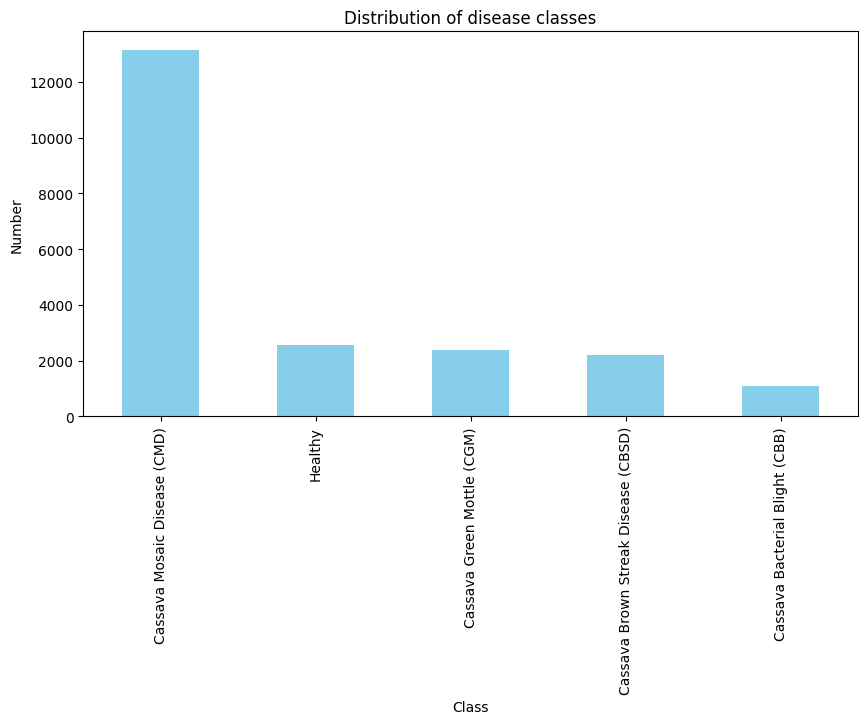

In [6]:
import matplotlib.pyplot as plt
import json

with open('/kaggle/input/competitions/cassava-leaf-disease-classification/label_num_to_disease_map.json') as input:
    label_map = json.load(input)
    
label_map = {int(k): v for k, v in label_map.items()}
plt.figure(figsize=(10, 5))
train_data['label'].map(label_map).value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of disease classes')
plt.xlabel('Class')
plt.ylabel('Number')
plt.show()

Cassava Bacterial Blight (CBB)


(600, 800, 3)

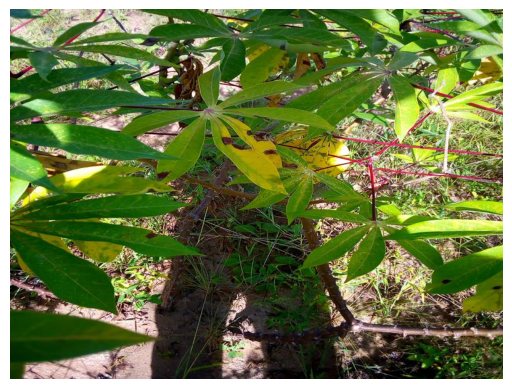

In [7]:
from PIL import Image
img = Image.open('/kaggle/input/competitions/cassava-leaf-disease-classification/train_images/' + train_data['image_id'].iloc[0])
plt.imshow(img)
plt.axis('off')
print(label_map[train_data['label'].iloc[0]])
i = np.array(img)
i.shape

In [8]:
# stratification
from sklearn.model_selection import StratifiedKFold
train_data['fold'] = -1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for num, (idx_train, idx_val) in enumerate(skf.split(train_data, train_data['label'])):
    train_data.loc[idx_val, 'fold'] = num
print(train_data['fold'].unique())

[3 2 1 0 4]


In [9]:
import torch
from torch.utils.data import DataLoader, Dataset
import cv2

class CassavaDataset(Dataset):
    def __init__(self, data, data_root, transforms=None):
        self.data = data
        self.data_root = data_root
        self.transforms = transforms

    
    def __len__(self):
        return len(self.data)


    def __getitem__(self, index):
        row = self.data.iloc[index]
        img_path = f'{self.data_root}/{row['image_id']}'
        img = cv2.imread(img_path) # open file, PIL image(0-255)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # casting to RGB

        if self.transforms:
            img = self.transforms(img)

        label = torch.tensor(row['label']).long()
        
        return img, label
        

In [10]:
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn


transform_train = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(), # PIL image -> Tensor + normalization([0, 255] -> [0.0, 1.0])
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)

transform_val = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]
)

path = '/kaggle/input/competitions/cassava-leaf-disease-classification/train_images/'

In [ ]:
# bulding model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 10
print('Using device:', device)
fold_results = []

for FOLD in range(5):
    print('-' * 50)
    print(f'FOLD: {FOLD}')
    print('-' * 50)
    
    train_df = train_data[train_data['fold'] != FOLD].reset_index(drop=True)
    val_df = train_data[train_data['fold'] == FOLD].reset_index(drop=True)
    
    train_ds = CassavaDataset(train_df, path, transforms=transform_train)
    val_ds = CassavaDataset(val_df, path, transforms=transform_val)
    
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

    model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, 5)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    best_acc = 0
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_acc = 100. * train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)

        # validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        val_acc = 100. * val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)
        print(f'\nEpoch: {epoch}\n')
        print(f'Train loss: {train_loss_avg}; Train accuracy: {train_acc}')
        print(f'Validation loss: {val_loss_avg}; Validation accuracy: {val_acc}\n')

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'efficientnet_b1{FOLD}_best.pth')
            print(f'Model with accuracy {best_acc} has been saved\n')
            
            from IPython.display import FileLink
            display(FileLink(f'efficientnet_b1{FOLD}_best.pth'))
        
        scheduler.step()
    fold_results.append(best_acc)
    print(f'\nFold {FOLD} best accuracy: {best_acc}\n')

print('-' * 50)
print('FINAL RESULTS')
print('-' * 50)
for i, acc in enumerate(fold_results):
    print(f'Fold {i + 1}: {acc}')
    
print(f'Mean accuracy: {np.mean(fold_results)}')